In [16]:
# Install/update Kaggle
!pip install -q --upgrade kaggle

# Setup Kaggle API
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download dataset
!kaggle datasets download -d puneet6060/intel-image-classification --force

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
100% 346M/346M [00:06<00:00, 55.1MB/s]



In [17]:
# Extract dataset
import zipfile
import os

zip_path = "/content/intel-image-classification.zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("/content")

print("Dataset extracted successfully.")

Dataset extracted successfully.


In [18]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Flatten,Dropout,BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications.vgg16 import VGG16

In [19]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator,img_to_array

In [20]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=False,
    width_shift_range=0.2,
    height_shift_range=0.2,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    directory='/content/seg_train/seg_train',
    class_mode='sparse',
    batch_size=batch_size,
    target_size=(256, 256)
)

validation_generator = test_datagen.flow_from_directory(
    directory='/content/seg_test/seg_test',
    class_mode='sparse',
    batch_size=batch_size,
    target_size=(256, 256)
)

Found 14034 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


In [21]:
conv_base=VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(256,256,3)
)

In [22]:
conv_base.trainable=True
set_trainable = False

for layer in conv_base.layers:
  if layer.name == 'block5_conv1':
    set_trainable = True
  if set_trainable:
    layer.trainable = True
  else:
    layer.trainable = False

for layer in conv_base.layers:
  print(layer.name,layer.trainable)

input_layer_2 False
block1_conv1 False
block1_conv2 False
block1_pool False
block2_conv1 False
block2_conv2 False
block2_pool False
block3_conv1 False
block3_conv2 False
block3_conv3 False
block3_pool False
block4_conv1 False
block4_conv2 False
block4_conv3 False
block4_pool False
block5_conv1 True
block5_conv2 True
block5_conv3 True
block5_pool True


In [23]:
model=Sequential([
    conv_base,
    Flatten(),
    Dense(150,activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(75,activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(30,activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(6,activation='softmax'),
])

In [24]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 8, 8, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 150)            │     4,915,350 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 150)            │           600 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 75)             │        11,325 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 75)             │           300 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 75)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 30)             │         2,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 30)             │           120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │           186 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,644,849 (74.94 MB)

 Trainable params: 12,009,075 (45.81 MB)

 Non-trainable params: 7,635,774 (29.13 MB)

In [25]:
model.compile(optimizer='adam',metrics=['accuracy'],loss='sparse_categorical_crossentropy')

In [26]:
callback=EarlyStopping(
    monitor='val_loss',
    verbose=1,
    mode='min',
    min_delta=0.01,
    patience=10,
    restore_best_weights=True
)

In [ ]:
history=model.fit(train_generator,verbose=1,validation_data=validation_generator,epochs=100,callbacks=callback,batch_size=32)

Epoch 1/100
439/439 ━━━━━━━━━━━━━━━━━━━━ 302s 689ms/step - accuracy: 0.9280 - loss: 0.2150 - val_accuracy: 0.9057 - val_loss: 0.2813
Epoch 2/100
439/439 ━━━━━━━━━━━━━━━━━━━━ 300s 683ms/step - accuracy: 0.9362 - loss: 0.1945 - val_accuracy: 0.9013 - val_loss: 0.3262
Epoch 3/100
439/439 ━━━━━━━━━━━━━━━━━━━━ 326s 692ms/step - accuracy: 0.9349 - loss: 0.1936 - val_accuracy: 0.9067 - val_loss: 0.2895
Epoch 4/100
439/439 ━━━━━━━━━━━━━━━━━━━━ 302s 687ms/step - accuracy: 0.9383 - loss: 0.1855 - val_accuracy: 0.9040 - val_loss: 0.3348
Epoch 5/100
439/439 ━━━━━━━━━━━━━━━━━━━━ 301s 685ms/step - accuracy: 0.9437 - loss: 0.1683 - val_accuracy: 0.9093 - val_loss: 0.2754
Epoch 6/100
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 626ms/step - accuracy: 0.9460 - loss: 0.1640

In [28]:
import matplotlib.pyplot as plt

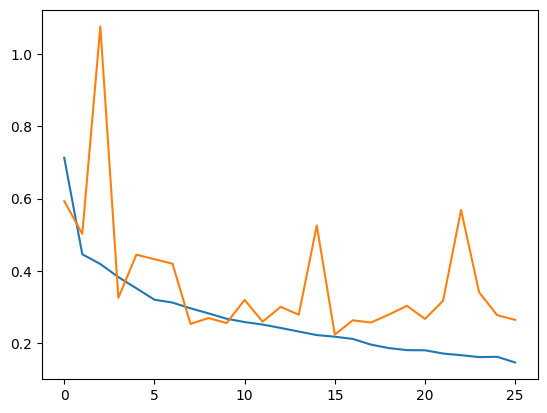

In [31]:
plt.plot(history.history['loss'],label='train')
plt.plot(history.history['val_loss'],label='test')

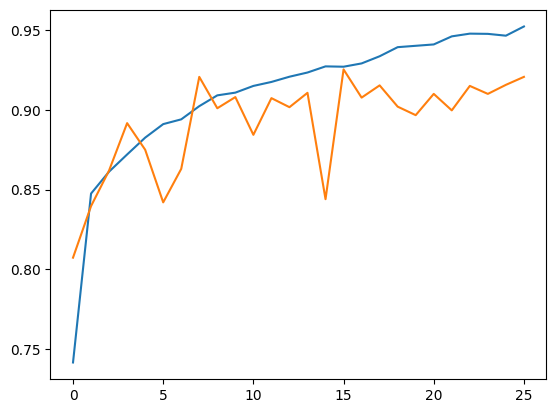

In [30]:
plt.plot(history.history['accuracy'],label='accuracy')
plt.plot(history.history['val_accuracy'],label='val_accuracy')